------ Question 13 ------
Shape of returns: (51, 4)
Highest Mean Return: AMZN
Highest Volatility: AAPL

Annualised Sharpe:
 AAPL     0.824485
MSFT     0.397113
GOOGL   -0.537553
AMZN     1.794045
dtype: float64

------ Question 14 ------
Lowest correlation pair: ('AAPL', 'MSFT')

First 3 portfolio returns:
 2023-01-09    0.017025
2023-01-16    0.013732
2023-01-23    0.014703
Freq: W-MON, dtype: float64

Monthly Mean: 0.013975, Std: 0.039023

------ Question 15 ------


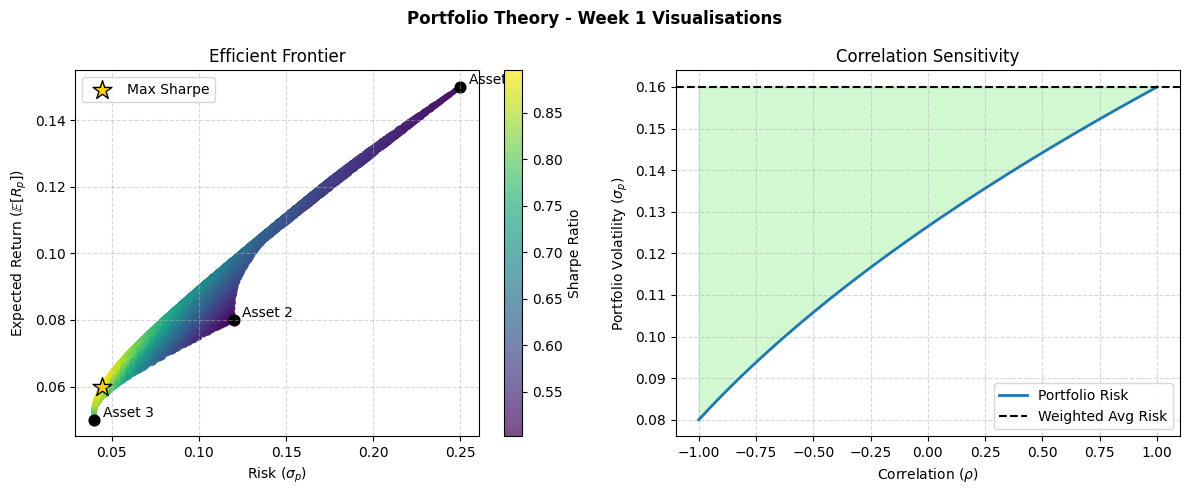

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("------ Question 13 ------")
np.random.seed(0)
dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')
mu_weekly = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly = np.array([0.04, 0.03, 0.02, 0.025])

returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))
prices_sim = 100 * np.cumprod(1 + returns_sim, axis=0)
df = pd.DataFrame(prices_sim, index=dates, columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN'])

# a) Returns
returns_df = df.pct_change().dropna()
print("Shape of returns:", returns_df.shape)

# b) Stats
print(f"Highest Mean Return: {returns_df.mean().idxmax()}")
print(f"Highest Volatility: {returns_df.std().idxmax()}")

# c) Sharpe Ratios
ann_ret = returns_df.mean() * 52
ann_vol = returns_df.std() * np.sqrt(52)
sharpe = (ann_ret - 0.02) / ann_vol
print("\nAnnualised Sharpe:\n", sharpe)


print("\n------ Question 14 ------")
# a) Correlation
corr = returns_df.corr()
lowest_pair = corr.unstack().idxmin() # unstack flattens it to easily find the min pair
print(f"Lowest correlation pair: {lowest_pair}")

# b) Equal-weight portfolio (25% each is just the row-wise mean)
port_ret = returns_df.mean(axis=1)
print("\nFirst 3 portfolio returns:\n", port_ret.head(3))

# c) Monthly resampling (Add 1, multiply them together, subtract 1)
monthly_ret = (port_ret + 1).resample('ME').prod() - 1
print(f"\nMonthly Mean: {monthly_ret.mean():.6f}, Std: {monthly_ret.std():.6f}")


print("\n------ Question 15 ------")
# --- Data Setup ---
mu_3 = np.array([0.15, 0.08, 0.05])
cov_3 = np.array([
    [0.0625, 0.0120, 0.0010],
    [0.0120, 0.0144, 0.00096],
    [0.0010, 0.00096, 0.0016]
])

# --- Simulations ---
np.random.seed(42)
weights = np.random.dirichlet(np.ones(3), size=20000)

# Vectorized math for the 20k portfolios
sim_ret = weights @ mu_3
sim_vol = np.sqrt(np.sum(weights * (weights @ cov_3), axis=1))
sim_sharpe = (sim_ret - 0.02) / sim_vol

best_idx = np.argmax(sim_sharpe)
asset_vols = np.sqrt(np.diag(cov_3))

# Correlation array math
w1, w2 = 0.6, 0.4
sig1, sig2 = 0.20, 0.10
rho = np.linspace(-1, 1, 200)

rho_vol = np.sqrt((w1*sig1)**2 + (w2*sig2)**2 + 2*w1*w2*sig1*sig2*rho)
avg_risk = (w1*sig1) + (w2*sig2)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Portfolio Theory - Week 1 Visualisations', fontweight='bold')

# Subplot 1: Scatter
sc = ax1.scatter(sim_vol, sim_ret, c=sim_sharpe, cmap='viridis', s=8, alpha=0.7)
fig.colorbar(sc, ax=ax1, label='Sharpe Ratio')
ax1.scatter(sim_vol[best_idx], sim_ret[best_idx], marker='*', color='gold', s=200, ec='black', label='Max Sharpe')

ax1.scatter(asset_vols, mu_3, color='black', s=60)
for i, txt in enumerate(['Asset 1', 'Asset 2', 'Asset 3']):
    ax1.annotate(txt, (asset_vols[i], mu_3[i]), xytext=(6, 2), textcoords='offset points')

ax1.set(xlabel=r'Risk ($\sigma_p$)', ylabel=r'Expected Return ($\mathbb{E}[R_p]$)', title='Efficient Frontier')
ax1.grid(True, ls='--', alpha=0.5)
ax1.legend()

# Subplot 2: Line
ax2.plot(rho, rho_vol, lw=2, label='Portfolio Risk')
ax2.axhline(avg_risk, color='black', ls='--', label='Weighted Avg Risk')
ax2.fill_between(rho, rho_vol, avg_risk, color='lightgreen', alpha=0.4)

ax2.set(xlabel=r'Correlation ($\rho$)', ylabel=r'Portfolio Volatility ($\sigma_p$)', title='Correlation Sensitivity')
ax2.grid(True, ls='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.savefig('week1_plots.png')
plt.show()